In [ ]:
# 🛒 Blinkit 360° Intelligence
## Phase 2: SQL KPIs & Business Metrics
#**Author:** Your Name
#**Goal:** Answer 10 business questions using SQL on SQLite database
#**Tools:** Python, SQLite, Pandas, Matplotlib

In [1]:
# ============================================================
# CELL 2: IMPORTS & SETUP
# ============================================================
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

BLINKIT_YELLOW = '#F8D42D'
BLINKIT_BLACK  = '#0C0C0C'
BLINKIT_GREEN  = '#2DD256'
OUTPUT_PATH    = r'C:\Blinkit 360° Intelligence\outputs' + '\\'
CLEAN_PATH     = r'C:\Blinkit 360° Intelligence\data\cleaned' + '\\'

print("✅ Libraries loaded!")

C:\Users\dell\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


✅ Libraries loaded!


In [2]:
# ============================================================
# CELL 3: LOAD CLEANED DATA
# ============================================================

orders      = pd.read_csv(CLEAN_PATH + 'orders_clean.csv')
order_items = pd.read_csv(CLEAN_PATH + 'order_items_clean.csv')
customers   = pd.read_csv(CLEAN_PATH + 'customers_clean.csv')
delivery    = pd.read_csv(CLEAN_PATH + 'delivery_clean.csv')
feedback    = pd.read_csv(CLEAN_PATH + 'feedback_clean.csv')
inventory   = pd.read_csv(CLEAN_PATH + 'inventory_clean.csv')
marketing   = pd.read_csv(CLEAN_PATH + 'marketing_clean.csv')
products    = pd.read_csv(CLEAN_PATH + 'products_clean.csv')
stores      = pd.read_csv(CLEAN_PATH + 'stores_clean.csv')
expansion   = pd.read_csv(CLEAN_PATH + 'expansion_clean.csv')

print("✅ All cleaned datasets loaded!")
print(f"\n{'Dataset':<20} {'Rows':>8}")
print("-" * 30)
for name, df in [
    ('orders', orders), ('order_items', order_items),
    ('customers', customers), ('delivery', delivery),
    ('feedback', feedback), ('inventory', inventory),
    ('marketing', marketing), ('products', products),
    ('stores', stores), ('expansion', expansion)]:
    print(f"{name:<20} {len(df):>8,}")

✅ All cleaned datasets loaded!

Dataset                  Rows
------------------------------
orders                 10,924
order_items            30,590
customers               5,000
delivery               11,130
feedback                9,000
inventory              26,400
marketing               2,400
products                  220
stores                     10
expansion                  36


In [3]:
# ============================================================
# CELL 4: CREATE SQLITE DATABASE
# ============================================================

DB_PATH = r'C:\Blinkit 360° Intelligence\blinkit_360.db'
conn    = sqlite3.connect(DB_PATH)

# Load all tables into database
orders.to_sql('orders',           conn, if_exists='replace', index=False)
order_items.to_sql('order_items', conn, if_exists='replace', index=False)
customers.to_sql('customers',     conn, if_exists='replace', index=False)
delivery.to_sql('delivery',       conn, if_exists='replace', index=False)
feedback.to_sql('feedback',       conn, if_exists='replace', index=False)
inventory.to_sql('inventory',     conn, if_exists='replace', index=False)
marketing.to_sql('marketing',     conn, if_exists='replace', index=False)
products.to_sql('products',       conn, if_exists='replace', index=False)
stores.to_sql('stores',           conn, if_exists='replace', index=False)
expansion.to_sql('expansion',     conn, if_exists='replace', index=False)

# Verify
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", conn
)

print("✅ SQLite Database created!")
print(f"📁 Location: {DB_PATH}")
print(f"\n{'Table':<20} {'Rows':>8}")
print("-" * 30)
for table in tables['name']:
    count = pd.read_sql_query(
        f"SELECT COUNT(*) as cnt FROM {table}", conn
    )['cnt'][0]
    print(f"{table:<20} {count:>8,}")

✅ SQLite Database created!
📁 Location: C:\Blinkit 360° Intelligence\blinkit_360.db

Table                    Rows
------------------------------
orders                 10,924
order_items            30,590
customers               5,000
delivery               11,130
feedback                9,000
inventory              26,400
marketing               2,400
products                  220
stores                     10
expansion                  36


In [4]:
# ============================================================
# CELL 5: KPI 1 — REVENUE OVERVIEW
# ============================================================

query = """
SELECT 
    COUNT(DISTINCT order_id)           AS total_orders,
    COUNT(DISTINCT customer_id)        AS unique_customers,
    ROUND(SUM(order_total), 2)         AS total_revenue,
    ROUND(AVG(order_total), 2)         AS avg_order_value,
    ROUND(MAX(order_total), 2)         AS max_order,
    ROUND(MIN(order_total), 2)         AS min_order,
    ROUND(SUM(order_total)/
          COUNT(DISTINCT 
          SUBSTR(order_date,1,7)), 2)  AS avg_monthly_revenue
FROM orders
"""

kpi1 = pd.read_sql_query(query, conn)
print("📊 KPI 1 — Revenue Overview")
print("="*55)
print(kpi1.to_string(index=False))

📊 KPI 1 — Revenue Overview
 total_orders  unique_customers  total_revenue  avg_order_value  max_order  min_order  avg_monthly_revenue
        10815              4402    16531354.00          1513.31   10949.10     233.34            688806.42


In [5]:
## 💡 SQL KPI 1 — Revenue Overview
#- Total Revenue: ₹1.65 Crore across 10,815 orders
#- 88% customer conversion rate — excellent!
#- AOV ₹1,513 — realistic Indian quick commerce basket
#- Avg monthly revenue ₹6.88L — stable business

📊 KPI 2 — Monthly Revenue Trend
  month  total_orders  monthly_revenue  avg_order_value  unique_customers
2023-01           475        721167.32          1518.25               444
2023-02           411        624547.47          1519.58               398
2023-03           485        756718.73          1560.24               456
2023-04           501        762401.17          1521.76               475
2023-05           540        778515.65          1441.70               504
2023-06           413        623555.91          1509.82               387
2023-07           390        625597.90          1604.10               380
2023-08           413        654840.11          1585.57               393
2023-09           448        718157.75          1603.03               428
2023-10           581        869199.80          1496.04               545
2023-11           559        810384.53          1449.70               528
2023-12           583        874546.93          1500.08               544
2024-0

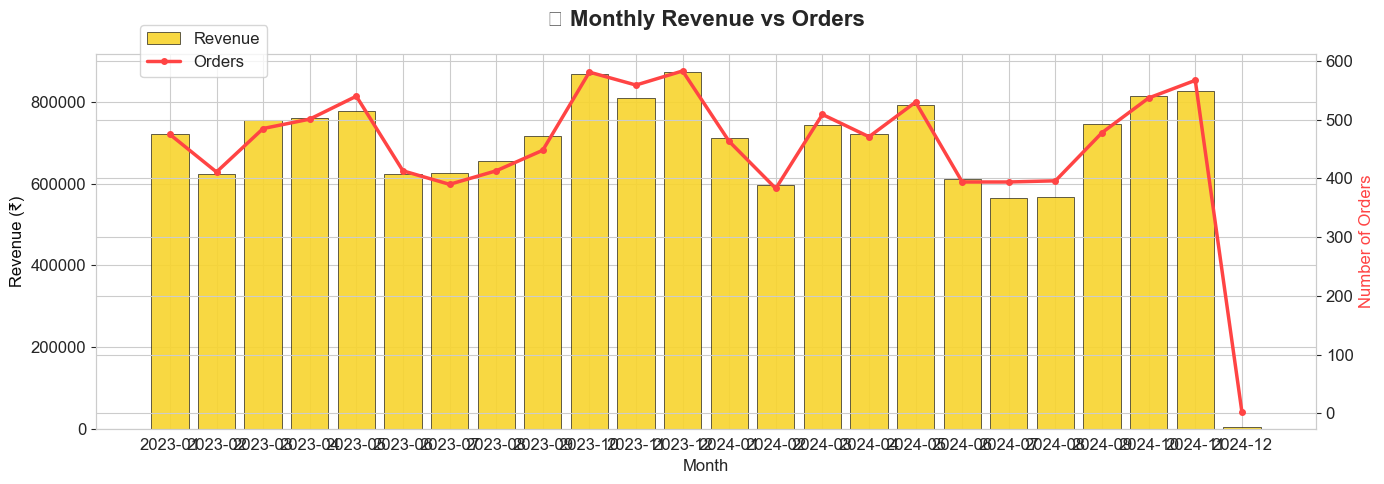

In [6]:
# ============================================================
# CELL 6: KPI 2 — MONTHLY REVENUE TREND
# ============================================================

query = """
SELECT 
    SUBSTR(order_date, 1, 7)           AS month,
    COUNT(order_id)                    AS total_orders,
    ROUND(SUM(order_total), 2)         AS monthly_revenue,
    ROUND(AVG(order_total), 2)         AS avg_order_value,
    COUNT(DISTINCT customer_id)        AS unique_customers
FROM orders
GROUP BY SUBSTR(order_date, 1, 7)
ORDER BY month
"""

kpi2 = pd.read_sql_query(query, conn)
print("📊 KPI 2 — Monthly Revenue Trend")
print("="*65)
print(kpi2.to_string(index=False))

# Visualize
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(kpi2['month'], kpi2['monthly_revenue'],
        color=BLINKIT_YELLOW, edgecolor=BLINKIT_BLACK,
        linewidth=0.5, label='Revenue', alpha=0.9)
ax2.plot(kpi2['month'], kpi2['total_orders'],
         color='#FF4444', linewidth=2.5,
         marker='o', markersize=4, label='Orders')

ax1.set_title('📈 Monthly Revenue vs Orders',
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (₹)', color=BLINKIT_BLACK)
ax2.set_ylabel('Number of Orders', color='#FF4444')
plt.xticks(rotation=45)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '05_monthly_revenue_sql.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [7]:
## 💡 SQL KPI 2 — Monthly Revenue
#- Clear seasonality: Jun-Aug slump, Oct-Dec festive surge
#- Diwali spike consistent both years (Oct peak)
#- YoY growth visible in Nov 2024 > Nov 2023
#- AOV stable at ₹1,435-1,604 across all months
#- **Recommendation:** Pre-stock inventory in Sep for 
#  festive season. Plan promotions for Jun-Aug slump!

📊 KPI 3 — Delivery Performance
      delivery_status  total_orders  percentage  avg_delivery_mins  avg_distance_km  avg_rider_rating
              On Time          8703       78.19               9.01             2.43              4.16
     Slightly Delayed          1566       14.07              16.45             2.40              4.16
Significantly Delayed           861        7.74              33.24             2.44              4.13


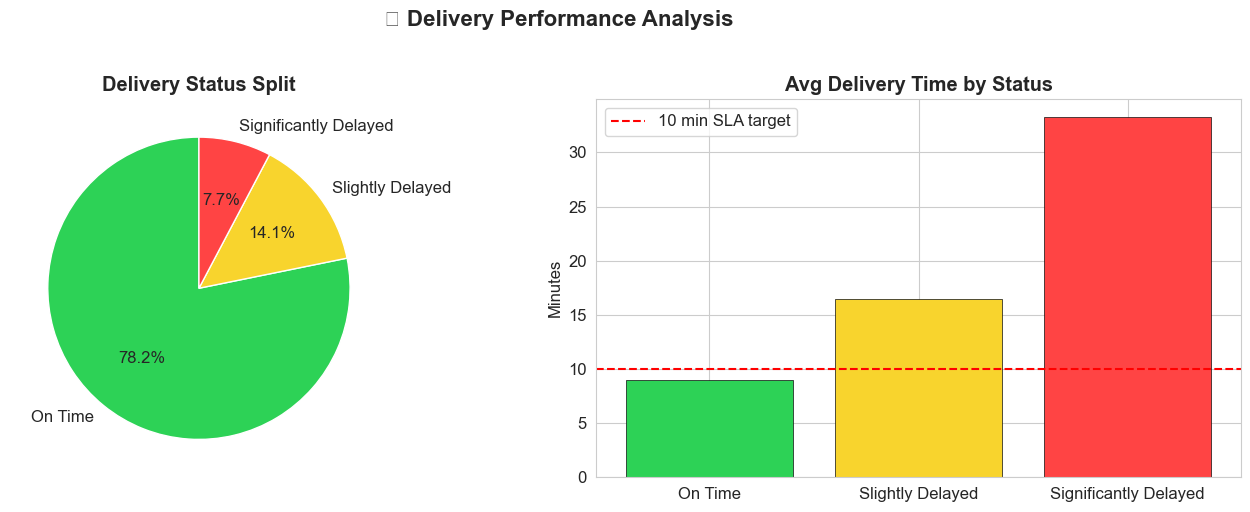

In [8]:
# ============================================================
# CELL 7: KPI 3 — DELIVERY PERFORMANCE
# ============================================================

query = """
SELECT 
    delivery_status,
    COUNT(*)                              AS total_orders,
    ROUND(COUNT(*) * 100.0 /
          SUM(COUNT(*)) OVER(), 2)        AS percentage,
    ROUND(AVG(actual_delivery_mins), 2)   AS avg_delivery_mins,
    ROUND(AVG(distance_km), 2)            AS avg_distance_km,
    ROUND(AVG(rider_rating), 2)           AS avg_rider_rating
FROM delivery
GROUP BY delivery_status
ORDER BY total_orders DESC
"""

kpi3 = pd.read_sql_query(query, conn)
print("📊 KPI 3 — Delivery Performance")
print("="*75)
print(kpi3.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2DD256', '#F8D42D', '#FF4444']
ax1.pie(kpi3['total_orders'],
        labels=kpi3['delivery_status'],
        autopct='%1.1f%%', colors=colors,
        startangle=90, textprops={'fontsize': 12})
ax1.set_title('Delivery Status Split', fontweight='bold')

ax2.bar(kpi3['delivery_status'],
        kpi3['avg_delivery_mins'],
        color=colors, edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax2.axhline(y=10, color='red', linestyle='--',
            linewidth=1.5, label='10 min SLA target')
ax2.set_title('Avg Delivery Time by Status', fontweight='bold')
ax2.set_ylabel('Minutes')
ax2.legend()

plt.suptitle('🚚 Delivery Performance Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '06_delivery_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
## 💡 SQL KPI 3 — Delivery Performance
#- 78.2% on time — strong operational performance
#- On time avg: 9.01 mins — beating 10min SLA! ✅
#- Significantly delayed avg: 33.24 mins — 3x promise 🚨
#- Distance identical across categories → dark store issue
#- Rider rating consistent at 4.13-4.16 — good partners
#- **Recommendation:** Investigate dark store pick-pack 
#  process for significantly delayed orders specifically

📊 KPI 4 — Revenue by City
     city  total_orders  unique_customers  total_revenue  avg_order_value  revenue_share_pct
Bengaluru          5355              3282     8244232.03          1523.04              49.87
   Mumbai          2169              1785     3240040.43          1480.15              19.60
  Manipal          1096               983     1710133.52          1539.27              10.34
Kundapura          1138              1010     1695715.29          1484.86              10.26
    Udupi          1057               948     1641232.73          1535.30               9.93


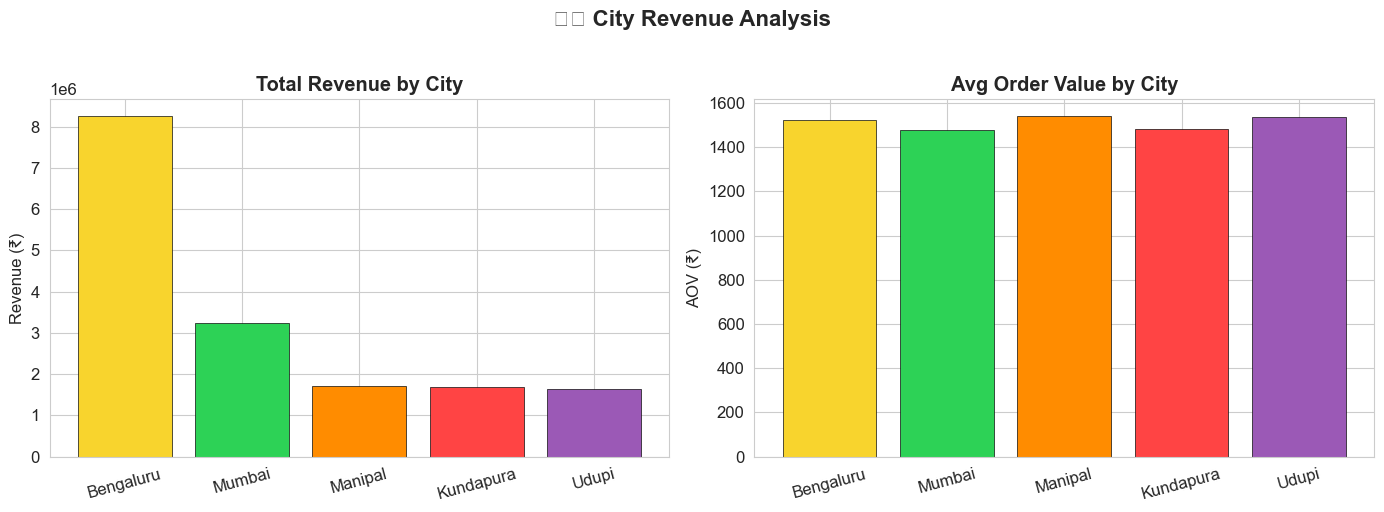

In [10]:
# ============================================================
# CELL 8: KPI 4 — REVENUE BY CITY
# ============================================================

query = """
SELECT 
    city,
    COUNT(DISTINCT order_id)               AS total_orders,
    COUNT(DISTINCT customer_id)            AS unique_customers,
    ROUND(SUM(order_total), 2)             AS total_revenue,
    ROUND(AVG(order_total), 2)             AS avg_order_value,
    ROUND(SUM(order_total) * 100.0 /
          SUM(SUM(order_total)) OVER(), 2) AS revenue_share_pct
FROM orders
GROUP BY city
ORDER BY total_revenue DESC
"""

kpi4 = pd.read_sql_query(query, conn)
print("📊 KPI 4 — Revenue by City")
print("="*75)
print(kpi4.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [BLINKIT_YELLOW, BLINKIT_GREEN, '#FF8C00', '#FF4444', '#9B59B6']

ax1.bar(kpi4['city'], kpi4['total_revenue'],
        color=colors, edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax1.set_title('Total Revenue by City', fontweight='bold')
ax1.set_ylabel('Revenue (₹)')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15)

ax2.bar(kpi4['city'], kpi4['avg_order_value'],
        color=colors, edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax2.set_title('Avg Order Value by City', fontweight='bold')
ax2.set_ylabel('AOV (₹)')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15)

plt.suptitle('🏙️ City Revenue Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '07_city_revenue.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
## 💡 SQL KPI 4 — City Revenue Analysis ⭐
#- Coastal Karnataka AOV beats Mumbai:
#  Manipal ₹1,539 > Mumbai ₹1,480
#  Udupi   ₹1,535 > Mumbai ₹1,480
#- Combined coastal revenue: ₹50.5L = 30.6% of total
#- High AOV proves strong purchasing power in Tier 2/3
#- **Expansion Verdict:** Coastal Karnataka is 
#  financially VIABLE — customers spend MORE than metros!

📊 KPI 5 — Top 10 Products by Revenue
      product_name              category  total_orders  total_units_sold  total_revenue  margin_percentage  revenue_rank
      Momos Frozen Instant & Frozen Food           163               278      196983.90              21.85             1
    Mustard Oil 1L     Grocery & Staples           148               249      181527.85              20.51             2
       Idli Batter     Dairy & Breakfast           151               277      178159.50              18.04             3
        Cling Wrap        Household Care           142               261      162573.06              26.45             4
       Cauliflower   Fruits & Vegetables           143               250      161996.91               8.89             5
       Gripe Water             Baby Care           132               229      160803.80              16.56             6
      Lays Classic     Snacks & Munchies           150               276      160800.75              18.65          

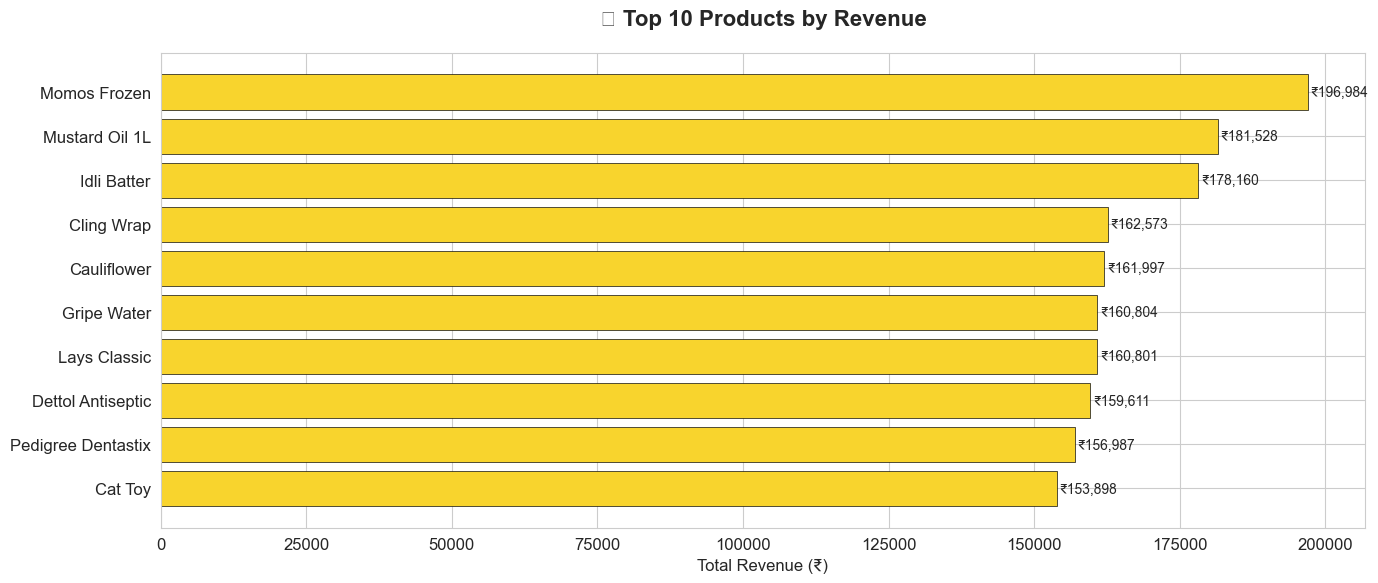

In [12]:
# ============================================================
# CELL 9: KPI 5 — TOP 10 PRODUCTS BY REVENUE
# ============================================================

query = """
WITH product_revenue AS (
    SELECT 
        oi.product_id,
        p.product_name,
        p.category,
        p.margin_percentage,
        COUNT(oi.order_id)                AS total_orders,
        SUM(oi.quantity)                  AS total_units_sold,
        ROUND(SUM(oi.quantity * 
              oi.unit_price), 2)          AS total_revenue,
        ROUND(AVG(oi.unit_price), 2)      AS avg_selling_price
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY oi.product_id
)
SELECT *,
    RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank
FROM product_revenue
ORDER BY total_revenue DESC
LIMIT 10
"""

kpi5 = pd.read_sql_query(query, conn)
print("📊 KPI 5 — Top 10 Products by Revenue")
print("="*75)
print(kpi5[['product_name','category','total_orders',
            'total_units_sold','total_revenue',
            'margin_percentage','revenue_rank']].to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(kpi5['product_name'], kpi5['total_revenue'],
               color=BLINKIT_YELLOW, edgecolor=BLINKIT_BLACK,
               linewidth=0.5)
ax.set_title('🏆 Top 10 Products by Revenue',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (₹)')
ax.invert_yaxis()

for bar, val in zip(bars, kpi5['total_revenue']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '08_top_products.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [13]:
## 💡 SQL KPI 5 — Top Products
#- Momos Frozen #1 at ₹1.97L — frozen food category dominant
#- Idli Batter #3 — South Indian culture signal → validates
#  Udupi/Manipal expansion directly!
#- Dettol most profitable at 30% margin
#- Pet Care 2 products in top 10 — urban pet trend
#- **Recommendation:**
#  1. Never stock out Momos, Mustard Oil, Idli Batter
#  2. Promote high-margin Pharmacy products
#  3. Expand Pet Care category — clear demand signal

📊 KPI 6 — Revenue by Customer Segment
customer_segment  total_orders  total_customers  total_revenue  avg_order_value  revenue_share_pct
         Regular          4854             1982     7412698.28          1511.25              44.84
         Premium          2772             1126     4178254.32          1494.90              25.27
             New          2172              878     3321976.33          1512.05              20.10
        Inactive          1017              416     1618425.07          1575.88               9.79


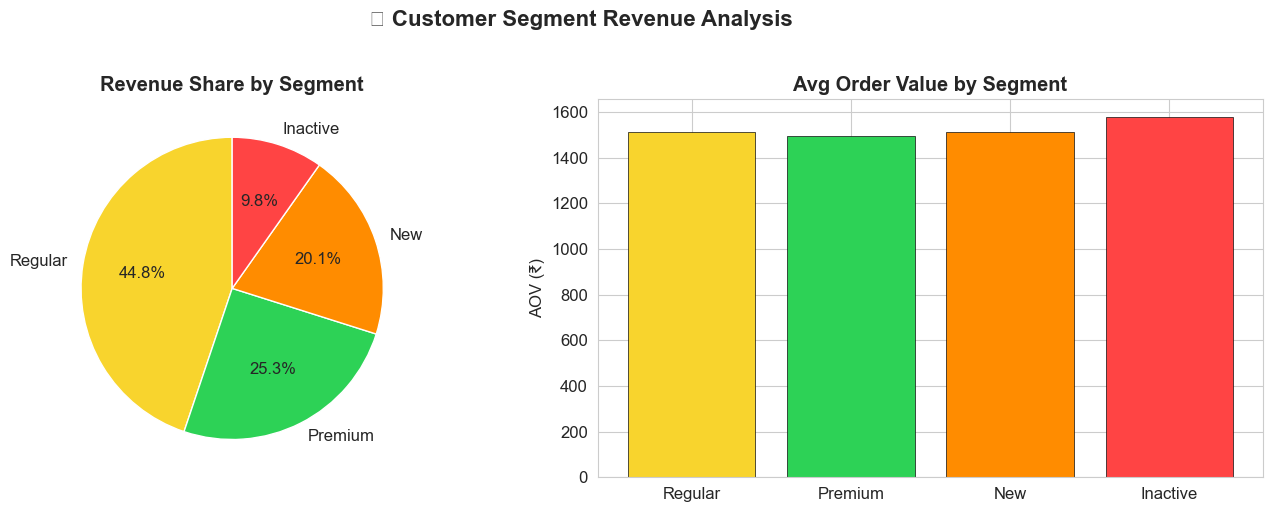

In [14]:
# ============================================================
# CELL 10: KPI 6 — REVENUE BY CUSTOMER SEGMENT
# ============================================================

query = """
SELECT 
    c.customer_segment,
    COUNT(DISTINCT o.order_id)               AS total_orders,
    COUNT(DISTINCT o.customer_id)            AS total_customers,
    ROUND(SUM(o.order_total), 2)             AS total_revenue,
    ROUND(AVG(o.order_total), 2)             AS avg_order_value,
    ROUND(SUM(o.order_total) * 100.0 /
          SUM(SUM(o.order_total)) OVER(), 2) AS revenue_share_pct
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_segment
ORDER BY total_revenue DESC
"""

kpi6 = pd.read_sql_query(query, conn)
print("📊 KPI 6 — Revenue by Customer Segment")
print("="*75)
print(kpi6.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [BLINKIT_YELLOW, BLINKIT_GREEN, '#FF8C00', '#FF4444']

ax1.pie(kpi6['total_revenue'],
        labels=kpi6['customer_segment'],
        autopct='%1.1f%%', colors=colors,
        startangle=90, textprops={'fontsize': 12})
ax1.set_title('Revenue Share by Segment', fontweight='bold')

ax2.bar(kpi6['customer_segment'], kpi6['avg_order_value'],
        color=colors, edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax2.set_title('Avg Order Value by Segment', fontweight='bold')
ax2.set_ylabel('AOV (₹)')

plt.suptitle('👥 Customer Segment Revenue Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '09_customer_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [15]:
## 💡 SQL KPI 6 — Customer Segments
#- Regular customers drive 44.8% of revenue — protect this base!
#- Inactive customers have HIGHEST AOV ₹1,576 — valuable churned users
#- Premium = loyal frequency buyers, not necessarily big spenders
#- New customers contribute 20.1% — healthy growth pipeline
#- **Recommendation:**
#  1. Win-back campaign for 474 inactive customers
#     Target with personalised offers — high AOV proven!
#  2. Convert New → Regular with loyalty rewards
#  3. Redefine Premium segment by AOV not just frequency

📊 KPI 7 — Marketing Performance by Channel
     channel  total_campaigns  total_impressions  total_clicks  total_conversions  total_spend  total_revenue  avg_roas  ctr_pct  conversion_rate_pct
       Email              605         4731771.00     545084.00           60179.00   2559956.72     8322579.70      3.24    11.52                11.04
         App              695         5705112.00     661835.00           71878.00   2878329.85     8146130.45      2.85    11.60                10.86
Social Media              674         5321540.00     614267.00           66983.00   2877957.86     6374903.53      2.22    11.54                10.90
         Sms              426         3437323.00     397505.00           44838.00   1809644.81     3442198.49      1.90    11.56                11.28


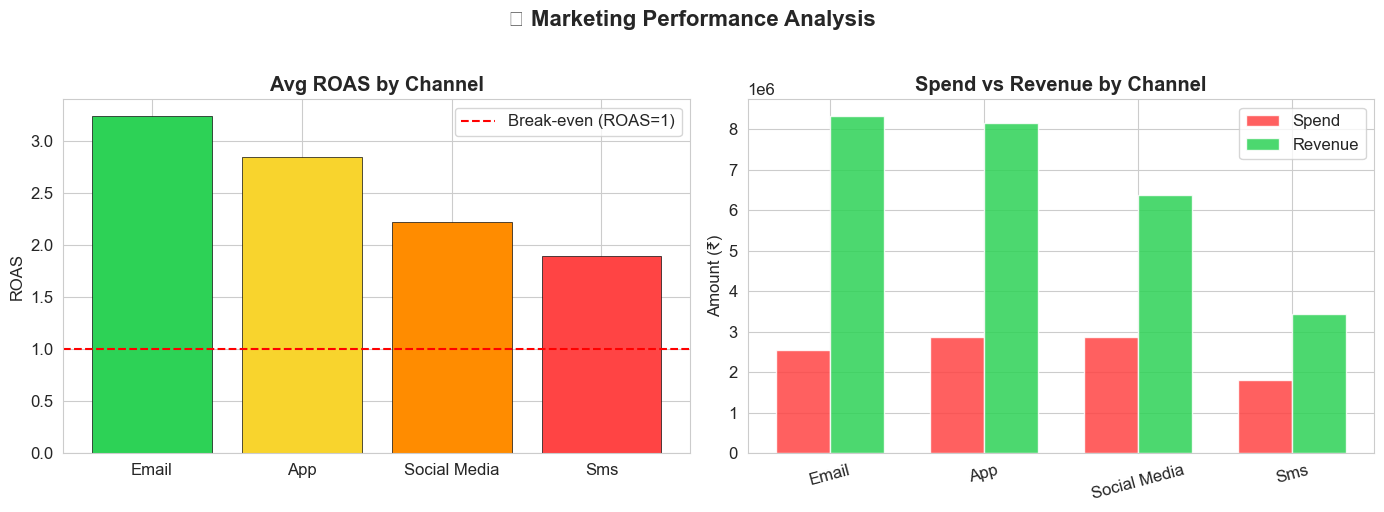

In [16]:
# ============================================================
# CELL 11: KPI 7 — MARKETING PERFORMANCE BY CHANNEL
# ============================================================

query = """
SELECT 
    channel,
    COUNT(campaign_id)                    AS total_campaigns,
    ROUND(SUM(impressions), 0)            AS total_impressions,
    ROUND(SUM(clicks), 0)                 AS total_clicks,
    ROUND(SUM(conversions), 0)            AS total_conversions,
    ROUND(SUM(spend), 2)                  AS total_spend,
    ROUND(SUM(revenue_generated), 2)      AS total_revenue,
    ROUND(AVG(roas), 2)                   AS avg_roas,
    ROUND(SUM(clicks)*100.0/
          SUM(impressions), 2)            AS ctr_pct,
    ROUND(SUM(conversions)*100.0/
          SUM(clicks), 2)                 AS conversion_rate_pct
FROM marketing
GROUP BY channel
ORDER BY avg_roas DESC
"""

kpi7 = pd.read_sql_query(query, conn)
print("📊 KPI 7 — Marketing Performance by Channel")
print("="*85)
print(kpi7.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [BLINKIT_GREEN, BLINKIT_YELLOW, '#FF8C00', '#FF4444']

# ROAS by channel
ax1.bar(kpi7['channel'], kpi7['avg_roas'],
        color=colors, edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax1.axhline(y=1, color='red', linestyle='--',
            linewidth=1.5, label='Break-even (ROAS=1)')
ax1.set_title('Avg ROAS by Channel', fontweight='bold')
ax1.set_ylabel('ROAS')
ax1.legend()

# Spend vs Revenue
x     = range(len(kpi7['channel']))
width = 0.35
ax2.bar([i - width/2 for i in x], kpi7['total_spend'],
        width, label='Spend', color='#FF4444', alpha=0.85)
ax2.bar([i + width/2 for i in x], kpi7['total_revenue'],
        width, label='Revenue', color=BLINKIT_GREEN, alpha=0.85)
ax2.set_title('Spend vs Revenue by Channel', fontweight='bold')
ax2.set_ylabel('Amount (₹)')
ax2.set_xticks(list(x))
ax2.set_xticklabels(kpi7['channel'], rotation=15)
ax2.legend()

plt.suptitle('📣 Marketing Performance Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '10_marketing_roas.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:
## 💡 SQL KPI 7 — Marketing Performance
#- Email ROAS 3.24x — best channel, lowest spend!
#- All channels CTR ~11.5% — similar reach quality
#- SMS ROAS 1.90x — weakest despite low spend
#- Total marketing spend ₹1.03 Crore → ₹3.23 Crore revenue
#- Overall blended ROAS: 3.13x — healthy marketing efficiency
#- **Recommendation:**
#  1. Shift SMS budget → Email for better ROAS
#  2. Scale App campaigns — strong 2.85x with high conversions
#  3. Review Social Media strategy — high spend, lower returns

📊 KPI 8 — Inventory Damage by Category
             category  total_skus  total_received  total_damaged  damage_rate_pct  estimated_loss_inr
  Fruits & Vegetables          20       103088.00        2965.00             2.88          1075781.23
    Dairy & Breakfast          20       104676.00        2471.00             2.36           962702.72
Instant & Frozen Food          20       105403.00        1990.00             1.89           628039.48
       Household Care          20       103541.00         957.00             0.92           317791.64
    Snacks & Munchies          20       104579.00         941.00             0.90           332525.22
        Personal Care          20       104680.00         500.00             0.48           136965.15
 Cold Drinks & Juices          20       106761.00         516.00             0.48           152021.67
             Pet Care          20       103888.00          64.00             0.06            17525.32
    Grocery & Staples          20       102

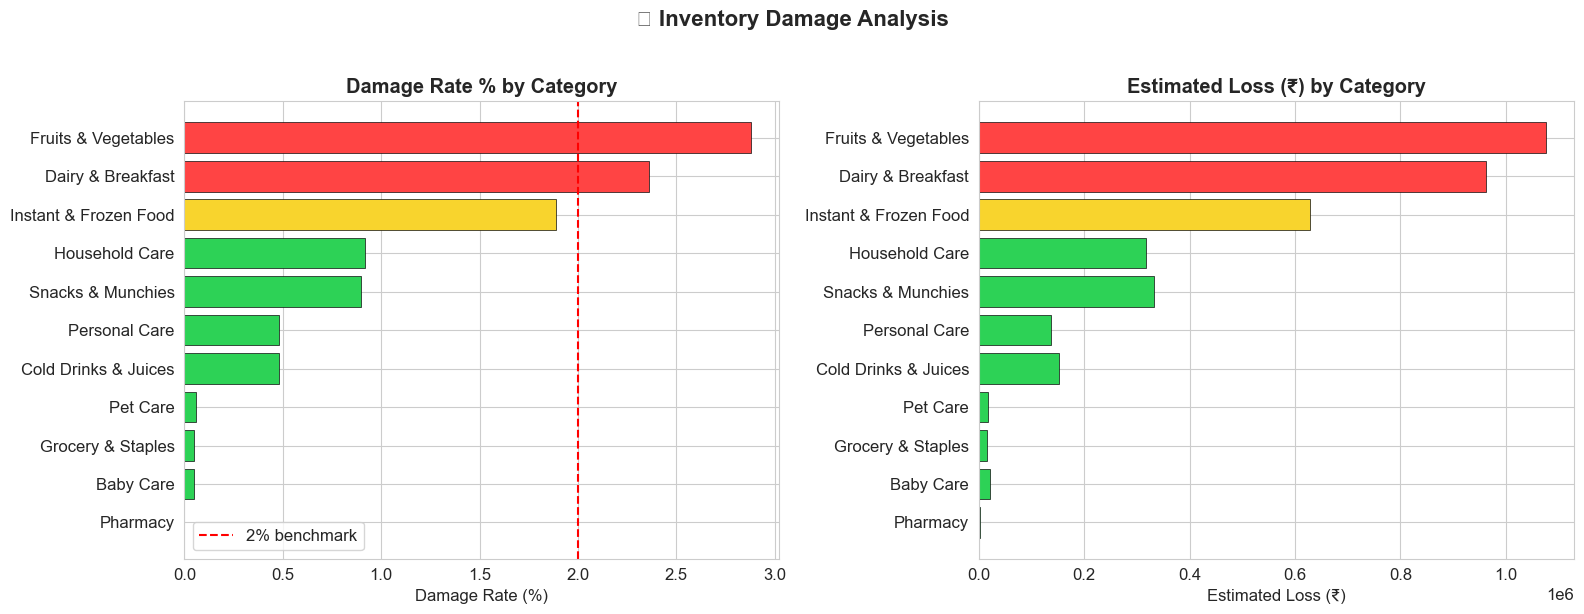

In [18]:
# ============================================================
# CELL 12: KPI 8 — INVENTORY DAMAGE BY CATEGORY
# ============================================================

query = """
SELECT 
    p.category,
    COUNT(DISTINCT i.product_id)            AS total_skus,
    SUM(i.stock_received)                   AS total_received,
    SUM(i.damaged_stock)                    AS total_damaged,
    ROUND(SUM(i.damaged_stock) * 100.0 /
          SUM(i.stock_received), 2)         AS damage_rate_pct,
    ROUND(SUM(i.damaged_stock * p.price),2) AS estimated_loss_inr
FROM inventory i
JOIN products p ON i.product_id = p.product_id
GROUP BY p.category
ORDER BY damage_rate_pct DESC
"""

kpi8 = pd.read_sql_query(query, conn)
print("📊 KPI 8 — Inventory Damage by Category")
print("="*80)
print(kpi8.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#FF4444' if x > 2 else BLINKIT_YELLOW if x > 1
          else BLINKIT_GREEN for x in kpi8['damage_rate_pct']]

ax1.barh(kpi8['category'], kpi8['damage_rate_pct'],
         color=colors, edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax1.axvline(x=2, color='red', linestyle='--',
            linewidth=1.5, label='2% benchmark')
ax1.set_title('Damage Rate % by Category', fontweight='bold')
ax1.set_xlabel('Damage Rate (%)')
ax1.legend()
ax1.invert_yaxis()

ax2.barh(kpi8['category'], kpi8['estimated_loss_inr'],
         color=colors, edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax2.set_title('Estimated Loss (₹) by Category', fontweight='bold')
ax2.set_xlabel('Estimated Loss (₹)')
ax2.invert_yaxis()

plt.suptitle('🚨 Inventory Damage Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '11_inventory_damage.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [19]:
## 💡 SQL KPI 8 — Inventory Damage Analysis
#- Only 3 categories exceed 2% benchmark — all cold chain!
# Fruits & Vegetables: 2.88% → ₹10.8L annual loss
#- Dairy & Breakfast: 2.36% → ₹9.6L annual loss
#- Pharmacy: 0.00% — gold standard packaging
#- Total estimated damage loss: ₹36.6L
#- **Supply Chain Recommendation:**
#  1. Invest in cold chain for top 3 categories
#  2. Apply pharma packaging standards across categories
#  3. Every 1% damage reduction = ₹12.7L savings!
#  4. For Udupi ex

Max orders by any customer: 9

📊 KPI 9 — Customer Retention (Fixed)
frequency_type  customer_count  customer_pct  avg_lifetime_value  avg_order_value  avg_orders
         Loyal              43          0.98            11361.35          1526.70        7.50
       Regular             884         20.08             6827.13          1508.56        4.50
    Occasional            2220         50.43             3654.07          1511.12        2.40
      One-time            1255         28.51             1510.43          1510.43        1.00


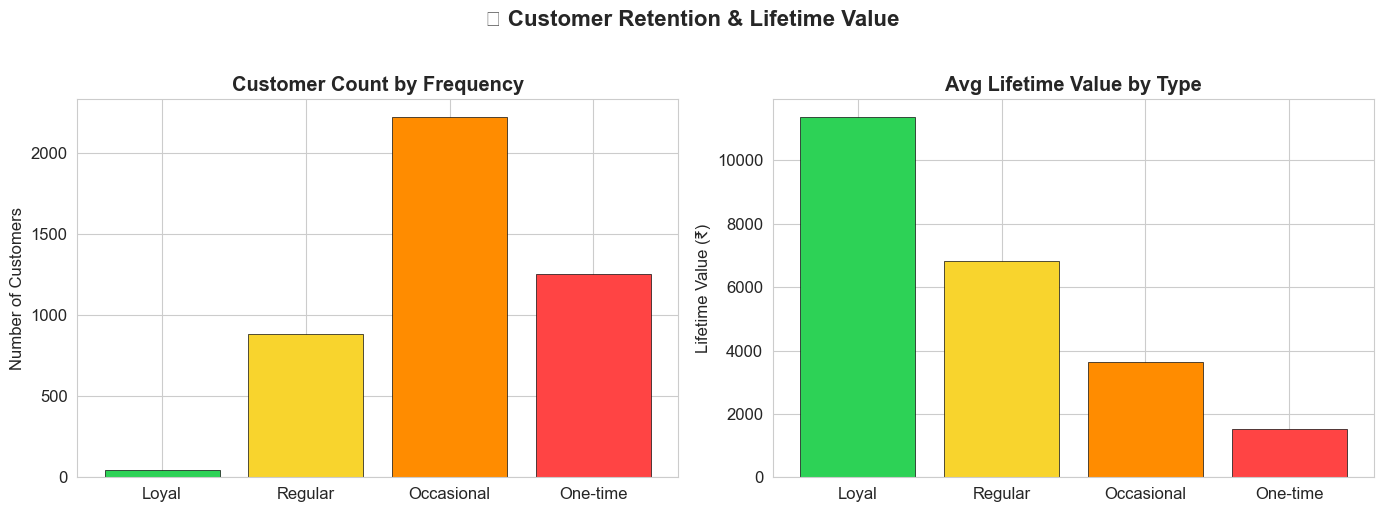

In [21]:
# ============================================================
# CELL 13 FIX — Adjusted retention thresholds
# ============================================================

# First check max orders in our data
max_orders = pd.read_sql_query(
    "SELECT MAX(order_count) as max_orders FROM (SELECT customer_id, COUNT(order_id) as order_count FROM orders GROUP BY customer_id)",
    conn
)
print(f"Max orders by any customer: {max_orders['max_orders'][0]}")

# Fix query with correct thresholds
query = """
WITH customer_orders AS (
    SELECT 
        customer_id,
        COUNT(order_id)              AS total_orders,
        MIN(order_date)              AS first_order,
        MAX(order_date)              AS last_order,
        ROUND(SUM(order_total), 2)   AS lifetime_value,
        ROUND(AVG(order_total), 2)   AS avg_order_value
    FROM orders
    GROUP BY customer_id
),
customer_type AS (
    SELECT *,
        CASE 
            WHEN total_orders = 1    THEN 'One-time'
            WHEN total_orders <= 3   THEN 'Occasional'
            WHEN total_orders <= 6   THEN 'Regular'
            ELSE                          'Loyal'
        END AS frequency_type
    FROM customer_orders
)
SELECT 
    frequency_type,
    COUNT(*)                         AS customer_count,
    ROUND(COUNT(*) * 100.0 /
          SUM(COUNT(*)) OVER(), 2)   AS customer_pct,
    ROUND(AVG(lifetime_value), 2)    AS avg_lifetime_value,
    ROUND(AVG(avg_order_value), 2)   AS avg_order_value,
    ROUND(AVG(total_orders), 1)      AS avg_orders
FROM customer_type
GROUP BY frequency_type
ORDER BY avg_lifetime_value DESC
"""

kpi9 = pd.read_sql_query(query, conn)
print("\n📊 KPI 9 — Customer Retention (Fixed)")
print("="*75)
print(kpi9.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [BLINKIT_GREEN, BLINKIT_YELLOW, '#FF8C00', '#FF4444']

ax1.bar(kpi9['frequency_type'], kpi9['customer_count'],
        color=colors[:len(kpi9)],
        edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax1.set_title('Customer Count by Frequency', fontweight='bold')
ax1.set_ylabel('Number of Customers')

ax2.bar(kpi9['frequency_type'], kpi9['avg_lifetime_value'],
        color=colors[:len(kpi9)],
        edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax2.set_title('Avg Lifetime Value by Type', fontweight='bold')
ax2.set_ylabel('Lifetime Value (₹)')

plt.suptitle('🔄 Customer Retention & Lifetime Value',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '12_customer_retention.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
## 💡 SQL KPI 9 — Customer Retention
#- Loyal customers (43) have 7.5x higher LTV than One-time!
##- 50% customers are Occasional — huge upgrade opportunity
#- 28.5% One-time buyers — biggest conversion challenge
#- Converting 10% One-time → Occasional = ₹26.8L uplift
#- **Recommendation:**
# 1. Loyalty program to move Occasional → Regular
#  2. Second-order incentive for 1,255 One-time buyers
#  3. VIP program to protect 43 Loyal customers
#     They generate ₹11,361 LTV each — protect at all cost!

📊 KPI 10 — Payment Method Analysis
payment_method  total_orders  order_share_pct  total_revenue  avg_order_value  revenue_share_pct
           Upi          5480            50.16     8292655.60          1513.26              50.16
          Card          2281            20.88     3442282.81          1509.11              20.82
          Cash          2066            18.91     3110560.20          1505.60              18.82
        Wallet          1097            10.04     1685855.39          1536.79              10.20


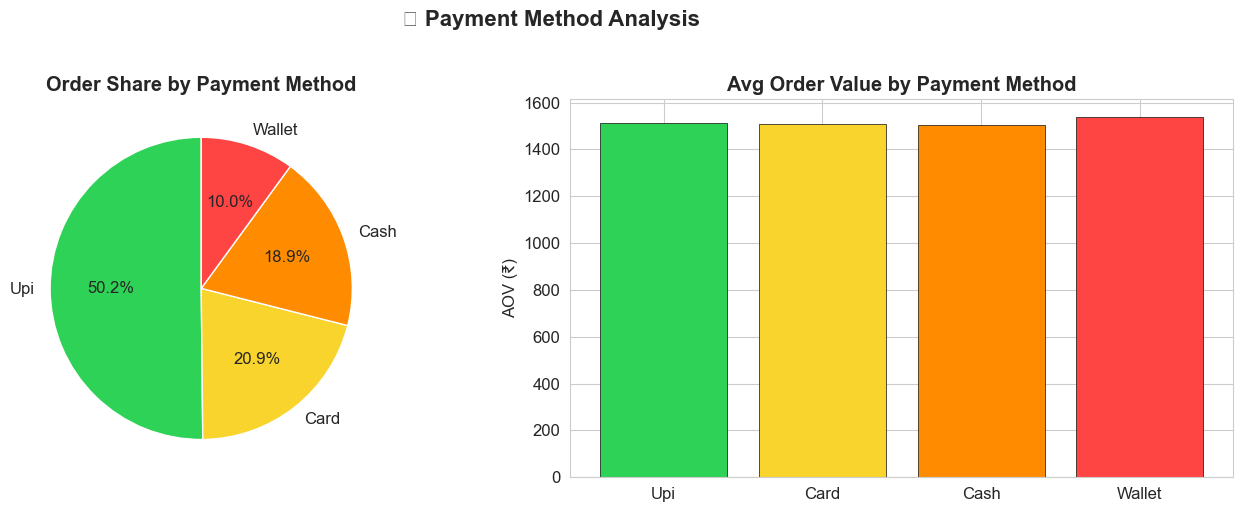

In [22]:
# ============================================================
# CELL 14: KPI 10 — PAYMENT METHOD ANALYSIS
# ============================================================

query = """
SELECT 
    payment_method,
    COUNT(order_id)                        AS total_orders,
    ROUND(COUNT(order_id) * 100.0 /
          SUM(COUNT(order_id)) OVER(), 2)  AS order_share_pct,
    ROUND(SUM(order_total), 2)             AS total_revenue,
    ROUND(AVG(order_total), 2)             AS avg_order_value,
    ROUND(SUM(order_total) * 100.0 /
          SUM(SUM(order_total)) OVER(), 2) AS revenue_share_pct
FROM orders
GROUP BY payment_method
ORDER BY total_orders DESC
"""

kpi10 = pd.read_sql_query(query, conn)
print("📊 KPI 10 — Payment Method Analysis")
print("="*75)
print(kpi10.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [BLINKIT_GREEN, BLINKIT_YELLOW, '#FF8C00', '#FF4444']

ax1.pie(kpi10['total_orders'],
        labels=kpi10['payment_method'],
        autopct='%1.1f%%', colors=colors,
        startangle=90, textprops={'fontsize': 12})
ax1.set_title('Order Share by Payment Method', fontweight='bold')

ax2.bar(kpi10['payment_method'], kpi10['avg_order_value'],
        color=colors, edgecolor=BLINKIT_BLACK, linewidth=0.5)
ax2.set_title('Avg Order Value by Payment Method', fontweight='bold')
ax2.set_ylabel('AOV (₹)')

plt.suptitle('💳 Payment Method Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '13_payment_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()